<a href="https://colab.research.google.com/github/eelah200/DeepLearning/blob/main/week13_practice_MakeDCGAN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import math
import torch
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch.nn as nn
import torch.optim as optim

import torchvision
import torchvision.utils as vutils
import torchvision.transforms as transforms
from torch.utils.data import Dataset, DataLoader
import torchvision.datasets as datasets

In [ ]:
# 디바이스 할당
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(device)

cuda:0


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
data_root = '/content/drive/MyDrive/Colab Notebooks/DeepLearning/img_celeba_1'

In [ ]:
image_sz = 64
# image_sz = 32
fake_sz = 100

In [ ]:
trans = transforms.Compose([transforms.Resize((image_sz, image_sz)),
                            transforms.ToTensor(),
                            transforms.CenterCrop(image_sz),
                            transforms.Normalize((0.5,0.5,0.5),(0.5,0.5,0.5))
])

In [ ]:
train_dataset = torchvision.datasets.ImageFolder(root=data_root,
                                                 transform=trans)

In [ ]:
# batch_size = 128
batch_size = 8

train_loader = DataLoader(train_dataset,
                          batch_size = batch_size,
                          shuffle = True)

In [ ]:
class Generator(nn.Module):
  def __init__(self):
    super(Generator, self).__init__()
    # 생성자를 구성하는 총 정의
    self.gen = nn.Sequential(
        nn.ConvTranspose2d(fake_sz, 512, kernel_size=4, bias=False),
        nn.BatchNorm2d(512),
        nn.ReLU(),

        nn.ConvTranspose2d(512, 256, kernel_size=4, stride=2, padding=1, bias=False),
        nn.BatchNorm2d(256),
        nn.ReLU(),

        nn.ConvTranspose2d(256, 128, kernel_size=4, stride=2, padding=1, bias=False),
        nn.BatchNorm2d(128),
        nn.ReLU(),

        nn.ConvTranspose2d(128, 64, kernel_size=4, stride=2, padding=1, bias=False),
        nn.BatchNorm2d(64),
        nn.ReLU(),

        nn.ConvTranspose2d(64, 3, kernel_size=4, stride=2, padding=1, bias=False),
        nn.Tanh()
    )
  def forward(self, x):
    return self.gen(x)



In [ ]:
# 판별자
class Discriminator(nn.Module):
  def __init__(self):
    super(Discriminator, self).__init__()
    self.disc = nn.Sequential(
          nn.Conv2d(3, 64, kernel_size=4, stride=2, padding=1),
          nn.BatchNorm2d(64),
          nn.LeakyReLU(0.2),

          nn.Conv2d(64, 128, kernel_size=4, stride=2, padding=1),
          nn.BatchNorm2d(128),
          nn.LeakyReLU(0.2),

          nn.Conv2d(128, 256, kernel_size=4, stride=2, padding=1),
          nn.BatchNorm2d(256),
          nn.LeakyReLU(0.2),

          nn.Conv2d(256, 512, kernel_size=4, stride=2, padding=1),
          nn.BatchNorm2d(512),
          nn.LeakyReLU(0.2),

          nn.Conv2d(512, 1, kernel_size=4),
          nn.Sigmoid()
      )
  def forward(self, x):
    return self.disc(x).view(-1, 1)

In [ ]:
def weights_init(m):
  classname = m.__class__.__name__
  if classname.find('Conv') !=-1:
    nn.init.normal_(m.weight.data, 0.0, 0.02)
  elif classname.find('BatchNorm') !=-1:
    nn.init.normal_(m.weight.data, 1.0,0.02)
    nn.init.constant_(m.bias.data, 0)

    # generator = Generator().to(device)
    # generator.apply(weights_init)
    # discriminator = Discriminator().to(device)
    # discriminator.apply(weights_init)
    # print(generator)
    # print(discriminator)

In [ ]:
generator = Generator().to(device)
generator.apply(weights_init)
discriminator = Discriminator().to(device)
discriminator.apply(weights_init)
print(generator)
print(discriminator)

Generator(
  (gen): Sequential(
    (0): ConvTranspose2d(100, 512, kernel_size=(4, 4), stride=(1, 1), bias=False)
    (1): BatchNorm2d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): ConvTranspose2d(512, 256, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (4): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU()
    (6): ConvTranspose2d(256, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (7): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (8): ReLU()
    (9): ConvTranspose2d(128, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (10): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (11): ReLU()
    (12): ConvTranspose2d(64, 3, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (13): Tanh()
  )
)
Discriminator(
  (disc): Sequential(
    (0): Con

In [ ]:
optim_g = optim.Adam(generator.parameters(), lr=0.0001, betas=(0.5,0.999))
optim_d = optim.Adam(discriminator.parameters(), lr=0.0001, betas=(0.5,0.999))

criterion = nn.BCELoss()

losses_g = []
losses_d = []

In [ ]:
# 판별자 학습
def train_discriminator(optimizer, data_real, data_fake):
  b_size = data_real.size(0)
  real_label = torch.ones(b_size, 1).to(device)
  fake_label = torch.zeros(b_size, 1).to(device)
  optimizer.zero_grad()
  output_real = discriminator(data_real)
  loss_real = criterion(output_real, real_label)
  output_fake = discriminator(data_fake)
  loss_fake = criterion(output_fake, fake_label)
  loss_total = (loss_real + loss_fake)/2
  loss_total.backward()
  optimizer.step()
  return loss_total

In [ ]:
# 판별자 생성
def train_generator(optimizer, data_fake):
  b_size = data_fake.size(0)
  real_label = torch.ones(b_size, 1).to(device)
  optimizer.zero_grad()
  output = discriminator(data_fake)
  loss = criterion(output, real_label)
  loss.backward()
  optimizer.step()
  return loss

In [ ]:
from torchvision.utils import save_image

In [ ]:
# 기존 DCGAN 학습 과정은 많은 양의 GPU 소모를 요구함.
# 10 epoch 별로 학습해 pth 파일로 저장
# 저장한 pth 파일에 학습을 누적시킴

import os

start_epoch = 0
epochs = 100

# 이어서 학습할 경우 체크포인트 불러오기
checkpoint_path = "/content/drive/MyDrive/4학년/딥러닝/Save_to_DCGAN/checkpoint_latest.pth"
if os.path.exists(checkpoint_path):
    checkpoint = torch.load(checkpoint_path)
    generator.load_state_dict(checkpoint['generator_state_dict'])
    discriminator.load_state_dict(checkpoint['discriminator_state_dict'])
    optim_g.load_state_dict(checkpoint['optimizer_g_state_dict'])
    optim_d.load_state_dict(checkpoint['optimizer_d_state_dict'])
    start_epoch = checkpoint['epoch'] + 1
    print(f"Resumed from epoch {start_epoch}")

for epoch in range(start_epoch, epochs):
    loss_g = 0.0
    loss_d = 0.0
    for idx, data in enumerate(train_loader):
        image, _ = data
        data_real = image.to(device)
        b_size = len(data_real)

        data_fake = generator(torch.randn(b_size, fake_sz, 1, 1).to(device))
        loss_d += train_discriminator(optim_d, data_real, data_fake)

        data_fake = generator(torch.randn(b_size, fake_sz, 1, 1).to(device))
        loss_g += train_generator(optim_g, data_fake)

    epoch_loss_g = loss_g / idx
    epoch_loss_d = loss_d / idx
    losses_g.append(epoch_loss_g)
    losses_d.append(epoch_loss_d)

    print(f"Epoch {epoch} of {epochs}")
    print(f"Generator loss: {epoch_loss_g:.8f} | Discriminator loss: {epoch_loss_d:.8f}")

    save_image(data_fake[:25],
               f'{epoch}.png',
               nrow=5,
               normalize=True)

    # 전체 상태 저장
    torch.save({
        'epoch': epoch,
        'generator_state_dict': generator.state_dict(),
        'discriminator_state_dict': discriminator.state_dict(),
        'optimizer_g_state_dict': optim_g.state_dict(),
        'optimizer_d_state_dict': optim_d.state_dict(),
        'loss_g': epoch_loss_g,
        'loss_d': epoch_loss_d
    }, checkpoint_path)


Resumed from epoch 90
Epoch 90 of 100
Generator loss: 5.70575571 | Discriminator loss: 0.06147147
Epoch 91 of 100
Generator loss: 5.57222939 | Discriminator loss: 0.08822562
Epoch 92 of 100
Generator loss: 5.85817051 | Discriminator loss: 0.05568830
Epoch 93 of 100
Generator loss: 5.79309225 | Discriminator loss: 0.07583079
Epoch 94 of 100
Generator loss: 5.93211031 | Discriminator loss: 0.06050408
Epoch 95 of 100
Generator loss: 5.73361158 | Discriminator loss: 0.07606018
Epoch 96 of 100
Generator loss: 5.93382168 | Discriminator loss: 0.05325641
Epoch 97 of 100
Generator loss: 5.91672134 | Discriminator loss: 0.07135523
Epoch 98 of 100
Generator loss: 5.85746145 | Discriminator loss: 0.08301274
Epoch 99 of 100
Generator loss: 6.01794958 | Discriminator loss: 0.04611932


In [ ]:
epochs = 100
for epoch in range(epochs):
    loss_g = 0.0
    loss_d = 0.0
    for idx, data in enumerate(train_loader):
        image, _ = data
        data_real = image.to(device)
        b_size = len(data_real)

        data_fake = generator(torch.randn(b_size, fake_sz, 1, 1).to(device))
        loss_d += train_discriminator(optim_d, data_real, data_fake)

        data_fake = generator(torch.randn(b_size, fake_sz, 1, 1).to(device))
        loss_g += train_generator(optim_g, data_fake)

    epoch_loss_g = loss_g / idx
    epoch_loss_d = loss_d / idx
    losses_g.append(epoch_loss_g)
    losses_d.append(epoch_loss_d)
    print(f"Epoch {epoch} of {epochs}")
    print(f"Generate loss: {epoch_loss_g:.8f} Discriminator loss: {epoch_loss_d:.8f}")
    save_image(data_fake[:25],
               f'{epoch}.png',
               nrow=5,
               normalize=True)

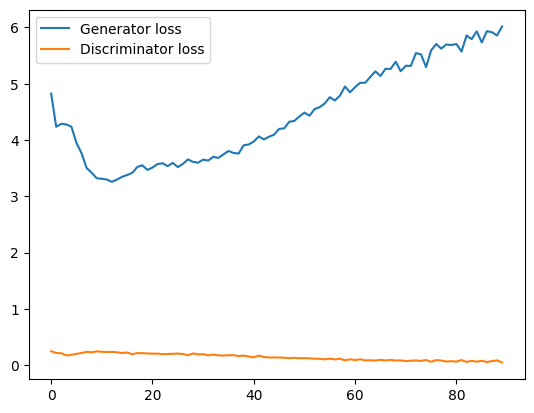

In [ ]:
plt.figure()
plt.plot(torch.Tensor(losses_g), label='Generator loss')
plt.plot(torch.Tensor(losses_d), label='Discriminator loss')
plt.legend()

In [ ]:
# fake_images = data_fake

# for i in range(10):
#   fake_images_img = np.reshape(fake_images.data.cpu().numpy()[i], (28, 28))
#   plt.imshow(fake_images_img, cmap = 'gray')
#   plt.show()

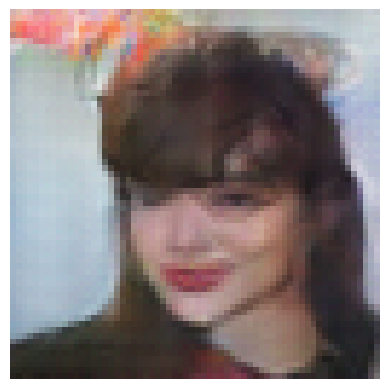

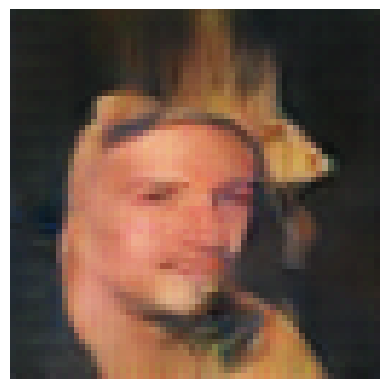

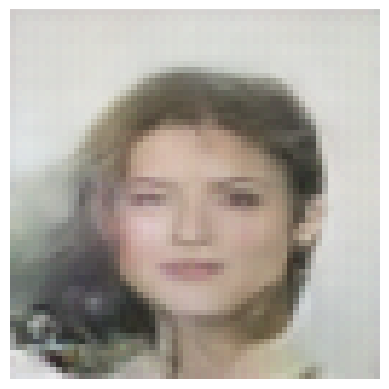

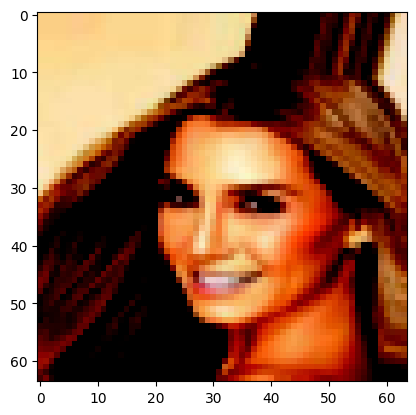

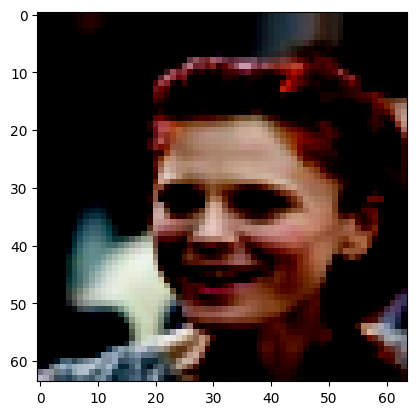

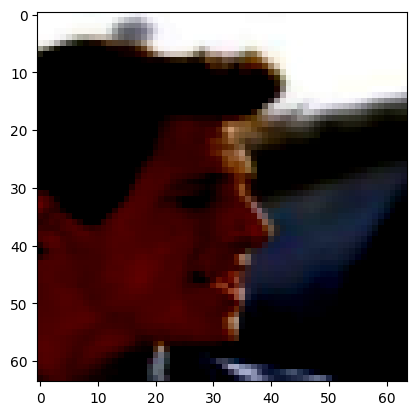

In [ ]:
fake_images = data_fake

# 가짜 이미지 출력
for i in range(3):
    fake_images_img = np.transpose(fake_images.data.cpu().numpy()[i], (1, 2, 0))  # (64, 64, 3)
    fake_images_img = (fake_images_img + 1) / 2
    plt.imshow(fake_images_img)
    plt.axis('off')
    plt.show()

# 원본 이미지 출력
for i in range(3):
  image, label = train_dataset[i]
  plt.imshow(np.transpose(image, (1,2,0)), cmap = 'gray')
  plt.show()

In [ ]:
from torchvision.utils import save_image

In [ ]:
save_image(data_fake, 'result_fake.png', nrow=3, normalize=True)

In [ ]:
save_image(data_real, 'result_real.png', nrow=3, normalize=True)

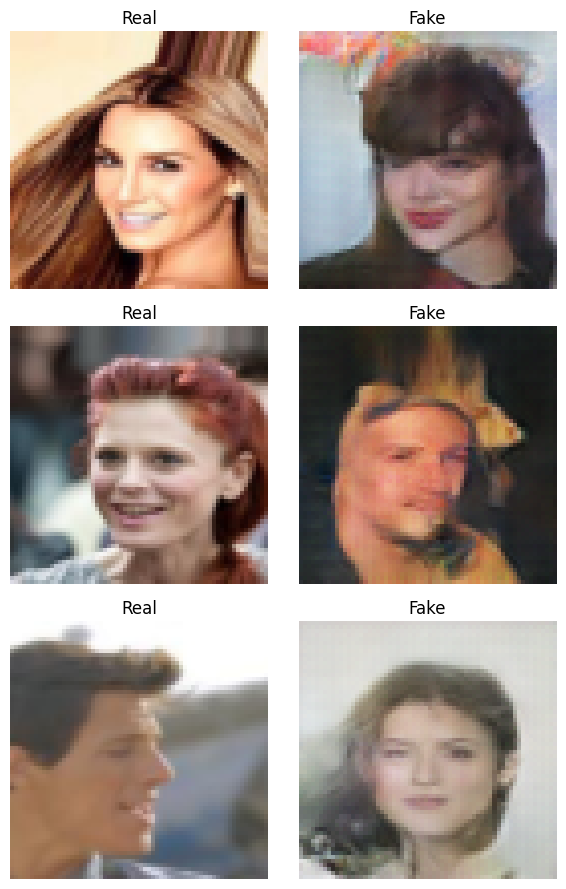

In [ ]:
fig, axes = plt.subplots(3, 2, figsize=(6, 9))

for i in range(3):
    real_img, _ = train_dataset[i]
    fake_img = fake_images[i]

    real_img = real_img.numpy().transpose(1, 2, 0)
    fake_img = fake_img.detach().cpu().numpy().transpose(1, 2, 0)

    real_img = (real_img + 1) / 2
    fake_img = (fake_img + 1) / 2

    axes[i, 0].imshow(real_img)
    axes[i, 0].set_title("Real")
    axes[i, 0].axis("off")

    axes[i, 1].imshow(fake_img)
    axes[i, 1].set_title("Fake")
    axes[i, 1].axis("off")

plt.tight_layout()
plt.show()
